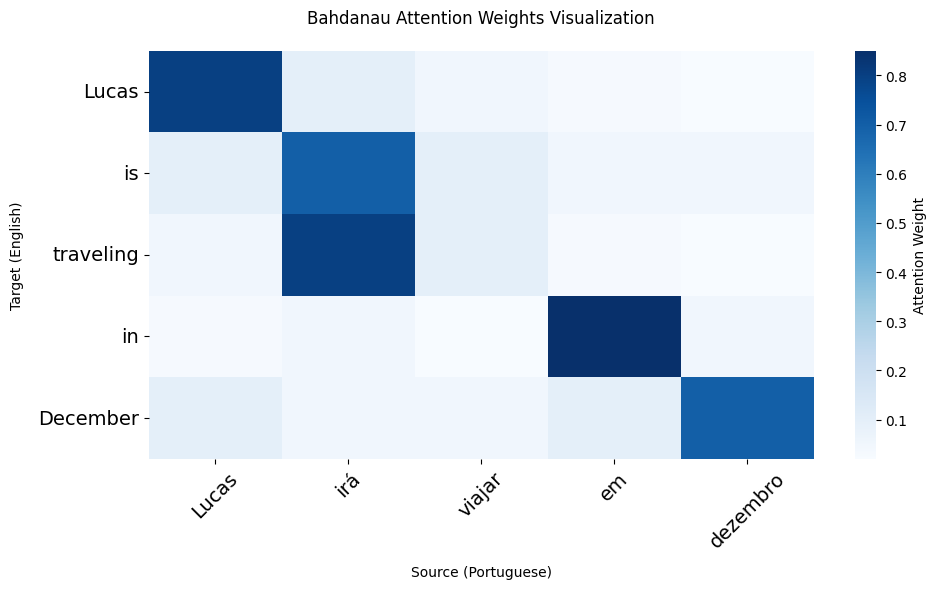

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_weights(source_sentence, target_sentence):
    # Split sentences into words
    source_words = source_sentence.split()
    target_words = target_sentence.split()

    # Create synthetic attention weights
    # This is a simplified example showing likely alignments
    attention_weights = np.array([
        [0.8, 0.1, 0.05, 0.03, 0.02],   # Lucas -> Lucas
        [0.1, 0.7, 0.1, 0.05, 0.05],    # is -> irá
        [0.05, 0.8, 0.1, 0.03, 0.02],   # traveling -> viajar
        [0.03, 0.05, 0.02, 0.85, 0.05], # in -> em
        [0.1, 0.05, 0.05, 0.1, 0.7],    # December -> dezembro
    ])

    # Create figure and axis
    plt.figure(figsize=(10, 6))

    # Create heatmap
    sns.heatmap(attention_weights,
                xticklabels=source_words,
                yticklabels=target_words,
                cmap='Blues',
                cbar_kws={'label': 'Attention Weight'})

    # Customize the plot
    plt.title('Bahdanau Attention Weights Visualization', pad=20)
    plt.xlabel('Source (Portuguese)', labelpad=10)
    plt.ylabel('Target (English)', labelpad=10)

    # Increase labels font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Rotate the tick labels for better readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    return plt

# Example sentences
source = "Lucas irá viajar em dezembro"
target = "Lucas is traveling in December"

# Create and show the plot
plt = plot_attention_weights(source, target)
plt.show()



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import numpy as np
from collections import defaultdict

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, n_layers=1, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))

        packed_embedded = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)

        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

        # Random initialization
        nn.init.normal_(self.W1.weight, mean=0, std=0.01)
        nn.init.normal_(self.W2.weight, mean=0, std=0.01)
        nn.init.normal_(self.v.weight, mean=0, std=0.01)

    def forward(self, hidden, encoder_outputs, mask):
        # Energy calculation: e_ij = v^T tanh(W₁h_j + W₂s_i)
        e = self.v(torch.tanh(self.W1(encoder_outputs) + self.W2(hidden).unsqueeze(1))).squeeze(-1)

        # Attention weights: a_ij = softmax(e_ij)
        a = F.softmax(e.masked_fill(mask == 0, -1e10), dim=1)

        return a

class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, attention, n_layers=1, dropout=0.1):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim + hidden_dim, hidden_dim, n_layers,
                         dropout=dropout if n_layers > 1 else 0,
                         batch_first=True)

        self.fc_out = nn.Linear(hidden_dim * 2 + embedding_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs, mask):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))

        attn_weights = self.attention(hidden[-1], encoder_outputs, mask)
        attn_weights = attn_weights.unsqueeze(1)

        context = torch.bmm(attn_weights, encoder_outputs)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        output = torch.cat((embedded.squeeze(1),
                          output.squeeze(1),
                          context.squeeze(1)), dim=1)

        prediction = self.fc_out(output)

        return prediction, hidden, attn_weights.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device, sos_idx, eos_idx, max_length=50):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx
        self.max_length = max_length

    def create_mask(self, src_lengths, max_len):
        batch_size = len(src_lengths)
        mask = torch.zeros(batch_size, max_len).to(self.device)
        for i, length in enumerate(src_lengths):
            mask[i, :length] = 1
        return mask

    def forward(self, src, src_lengths, trg=None):
        batch_size = src.shape[0]

        # Determine output sequence length
        if trg is not None:
            max_len = trg.shape[1]
        else:
            max_len = self.max_length

        # Initialize outputs tensor
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, max_len, trg_vocab_size).to(self.device)

        # Get encoder outputs
        encoder_outputs, hidden = self.encoder(src, src_lengths)

        # Create attention mask
        mask = self.create_mask(src_lengths, src.shape[1])

        # Initialize decoder input with SOS token
        input = torch.full((batch_size,), self.sos_idx, device=self.device)

        # Store attention weights for visualization
        attentions = torch.zeros(batch_size, max_len, src.shape[1]).to(self.device)

        # Generate output sequence one token at a time
        for t in range(1, max_len):
            # Get decoder output
            output, hidden, attention = self.decoder(input, hidden, encoder_outputs, mask)

            # Store output and attention
            outputs[:, t] = output
            attentions[:, t] = attention

            # Use argmax to get the most likely next token
            input = output.argmax(1)

            # Stop if all sequences in batch have generated EOS token
            if all((input == self.eos_idx)) and trg is None:
                break

        return outputs, attentions

def train_epoch(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for batch in iterator:
        optimizer.zero_grad()

        src, src_lengths = batch.src
        trg = batch.trg

        # Forward pass without teacher forcing
        output, _ = model(src, src_lengths, trg)

        output_dim = output.shape[-1]
        output = output[:, 1:].contiguous().view(-1, output_dim)
        trg = trg[:, 1:].contiguous().view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Hyperparameters
    EMBEDDING_DIM = 256
    HIDDEN_DIM = 512
    N_LAYERS = 2
    DROPOUT = 0.1

    # Create sample vocabularies
    src_vocab = defaultdict(lambda: len(src_vocab))
    tgt_vocab = defaultdict(lambda: len(tgt_vocab))

    # Add special tokens
    for vocab in [src_vocab, tgt_vocab]:
        vocab['<pad>'] = 0
        vocab['<sos>'] = 1
        vocab['<eos>'] = 2

    # Create model components
    encoder = Encoder(len(src_vocab), EMBEDDING_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
    attention = BahdanauAttention(HIDDEN_DIM)
    decoder = Decoder(len(tgt_vocab), EMBEDDING_DIM, HIDDEN_DIM, attention, N_LAYERS, DROPOUT)

    model = Seq2SeqAttention(
        encoder, decoder, device,
        sos_idx=tgt_vocab['<sos>'],
        eos_idx=tgt_vocab['<eos>']
    ).to(device)

    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab['<pad>'])

    print("Model initialized successfully!")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

if __name__ == "__main__":
    main()

Model initialized successfully!
Total parameters: 6833923
